# Dispatch-Optimierung von Batteriespeichern für Energiearbitrage und Spitzenlastkappung

## Zusammenfassung

Ein netzgekoppelter Gewerbestandort betreibt eine 2-MW-/8-MWh-Lithium-Ionen-Batterie parallel zu einer gemessenen elektrischen Last. Der Standort wird auf zwei Arten abgerechnet: über einen stündlichen **Energiepreis** des Day-Ahead-Marktes ($/MWh) und über eine monatliche **Leistungsgebühr** auf sein einzelnes höchstes Netzbezugsintervall ($/MW). Der Asset-Manager muss Stunde für Stunde entscheiden, wann die Batterie geladen wird (günstige Energie kaufen und den Netzbezug erhöhen) und wann sie entladen wird (teure Energie ausgleichen und den Netzbezug senken). Zwei Wertströme konkurrieren: **Energiearbitrage** (nachts günstig kaufen, zur Abendspitze entladen) und **Spitzenlastkappung** (das abgerechnete Netzmaximum begrenzen). Das Laden ist nicht kostenlos — durch den Umlaufwirkungsgrad gehen rund 10 % der gespeicherten Energie verloren —, sodass der Fahrplan eine echte Optimierung ist und keine Heuristik.

Dieses Notebook baut die Entscheidung durchgängig auf. Zunächst synthetisiert es eine realistische 24-stündige Day-Ahead-Preiskurve (mit Morgen- und Abendspitzen sowie einem nächtlichen Tiefpunkt) und ein korreliertes Standortlastprofil, anschließend profiliert es beide mit **PROC MEANS** und einem robusten 2,5-/97,5-Perzentil-Preisband via **PROC UNIVARIATE**. Der Kern ist ein lineares Programm in **PROC OPTMODEL**: Entscheidungsvariablen für stündliches Laden, Entladen und Ladezustand, dazu eine Variable für die abgerechnete Spitze, unter einer kumulativen Ladezustandsbilanz (mit getrenntem Lade-/Entladewirkungsgrad), Leistungs- und Kapazitätsgrenzen sowie einer Spitzendefinitions-Nebenbedingung. Die Zielfunktion maximiert die Arbitragemarge abzüglich der Leistungsgebühr. **PROC SQL** quantifiziert anschließend die Kosten von Ausgangs- gegenüber optimiertem Fall, und drei **PROC SGPLOT**-Panels visualisieren den Lade-/Entladefahrplan gegen den Preis, den Verlauf des Ladezustands und das geglättete Netzbezugsprofil.

**Ergebnis für den synthetischen Tag:** Der Optimierer füllt die Batterie in den günstigsten Nachtstunden, entlädt sowohl in die Morgen- als auch in die Abendpreisspitze, lädt durch das preisliche Mittagstal nach und hält — entscheidend — seine Ladeleistung zurück, sodass nie eine neue Netzspitze entsteht. Die täglichen Energiekosten sinken von **\$2.903,78 auf \$2.528,43** — **\$375,34 (12,9 %) Arbitrageersparnis** —, während das abgerechnete Netzmaximum von **3,59 MW auf 3,43 MW** fällt (um etwa **0,16 MW**), was bei der angenommenen Tagesanteils-Leistungsgebühr weitere **\$18,98** wert ist. Dasselbe Modell skaliert auf längere Horizonte, mehrere Preisszenarien oder degradationsbewusstes Zyklen, indem einfach die Indexmenge und die Nebenbedingungen erweitert werden.

## Datenquellen

Alle Daten sind **synthetisch** und werden in der ersten Codezelle inline mit `CALL STREAMINIT(20260605)` zur Reproduzierbarkeit erzeugt. Keine externen Dateien oder Netzwerkzugriffe. Ein Datensatz, `price_load`, mit 24 Stundenzeilen, die einen einzelnen Betriebstag darstellen.

| Variable | Typ | Einheiten | Beschreibung |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Stunde des Betriebstags (Horizontindex) |
| `price` | num | $/MWh | Day-Ahead-Energiepreis: nächtlicher Tiefpunkt, Morgen- + Abendspitzen, mit gaußschem Rauschen (untere Grenze bei $5) |
| `load` | num | MW | Elektrische Nachfrage des Standorts, korreliert mit der Tagesaktivität (untere Grenze bei 0,3 MW) |
| `day_type` | char | — | Tariffenster-Kennzeichen: `PeakTOU` (Stunden 17–21) vs. `OffPeak`, verwendet für die Zusammenfassung des Preisunterschieds zwischen Spitzen- und Nebenzeit |

Die Batterieparameter sind feste Modellkonstanten innerhalb von PROC OPTMODEL: 8 MWh nutzbare Kapazität, 2 MW maximale Lade-/Entladeleistung, 0,95 Lade- und 0,95 Entladewirkungsgrad (~90 % Umlauf), Anfangsladezustand 0 MWh und eine Leistungsgebühr von \$120/MW, angewendet auf die abgerechnete Netzspitze des Tages (der auf den Tag umgelegte Anteil einer monatlichen Leistungsgebühr).

# Dispatch-Optimierung von Batteriespeichern
## Energiearbitrage und Spitzenlastkappung für einen netzgekoppelten Standort

Ein Gewerbestandort betreibt hinter seinem Zähler eine **2-MW-/8-MWh-Batterie**. Seine Stromrechnung besteht aus zwei Teilen: einem stündlichen **Energiepreis** ($/MWh) und einer monatlichen **Leistungsgebühr** auf das einzelne höchste Netzbezugsintervall ($/MW). Der Betreiber möchte einen stündlichen Lade-/Entladefahrplan, der zwei Wertströme zugleich erfasst:

- **Arbitrage** — günstige Nachtenergie speichern und in teuren Spitzenstunden freigeben.
- **Spitzenlastkappung** — während der Nachfragespitze entladen, um das abgerechnete Netzmaximum zu senken.

Da der Umlaufwirkungsgrad ~10 % der gespeicherten Energie verliert, ist der Zielkonflikt nicht trivial und rechtfertigt eine echte Optimierung. Wir formulieren ihn als lineares Programm in **PROC OPTMODEL**, quantifizieren und visualisieren dann das Ergebnis.

> Alle nachstehenden Daten sind synthetisch und werden inline erzeugt — das Notebook ist vollständig eigenständig und läuft in wenigen Sekunden.

## 1. Erzeugen eines synthetischen Day-Ahead-Preis- und Lastprofils

Wir bauen einen Betriebstag (24 Stundenzeilen). Die Preiskurve hat einen nächtlichen Tiefpunkt sowie Morgen- + Abendspitzen; die Standortlast korreliert mit der Tagesaktivität. Ein fester Seed hält den Lauf reproduzierbar. Wir kennzeichnen außerdem das gesetzliche Time-of-Use-Spitzenfenster, damit wir später den Preisunterschied zwischen Spitzen- und Nebenzeit zusammenfassen können.

In [1]:
DATEN price_load;
    AUFRUFEN streaminit(20260605);
    LÄNGE day_type $12;
    AUSFÜHRUNG hour = 0 BIS 23;
        /* Diurnal energy price ($/MWh): morning + evening peaks */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        WENN price < 5 DANN price = 5;

        /* Site load (MW): overnight trough, evening ramp */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        WENN LOAD < 0.3 DANN LOAD = 0.3;

        WENN hour >= 17 UND hour <= 21 DANN day_type = 'Spitzenzeit';
        SONST day_type = 'Nebenzeit';
        AUSGABE;
    ENDE;
    ENTFERNEN BASE;
AUSFÜHREN;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Profilieren der Preis- und Lastverteilungen

Vor der Optimierung prüfen wir die Eingaben auf Plausibilität. Der Unterschied zwischen den günstigsten und den teuersten Stunden ist das, was die Arbitrage monetarisiert, und die maximale Last verankert die Chance zur Spitzenlastkappung.

In [2]:
TITEL "Verteilungsprofil von Preis und Last";
PROZEDUR MITTELWERTE DATEN=price_load n mean std MIN MAX maxdec=2;
    VAR price LOAD;
    BEZEICHNUNG price="Preis ($/MWh)" LOAD="Last (MW)";
AUSFÜHREN;
TITEL;

                                          Verteilungsprofil von Preis und Last                                          

                                                  The MEANS Procedure

 Variable  Label                N        Mean     Std Dev     Minimum     Maximum
 --------------------------------------------------------------------------------
 price     Preis ($/MWh)       24       46.29       15.81       18.57       79.27
 LOAD      Last (MW)           24        2.47        0.48        1.71        3.59
 --------------------------------------------------------------------------------




NOTE: Option TITLE changed to Verteilungsprofil von Preis und Last.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Preisunterschied zwischen Spitzen- und Nebenzeit

Die Gruppierung nach dem Time-of-Use-Kennzeichen zeigt, um wie viel reicher die Spitzenstunden gegenüber der Nebenzeit-Basislinie sind — das strukturelle Signal, das die Batterie ausnutzt.

In [3]:
TITEL "Preisunterschied: Spitzen- vs. Nebenzeit";
PROZEDUR MITTELWERTE DATEN=price_load mean MIN MAX maxdec=2;
    KLASSE day_type;
    VAR price;
    BEZEICHNUNG price="Preis ($/MWh)" day_type="Tariffenster";
AUSFÜHREN;
TITEL;

                                        Preisunterschied: Spitzen- vs. Nebenzeit                                        

                                                  The MEANS Procedure

                                        Analysis Variable : price Preis ($/MWh)

                                                  N
                                Tariffenster    Obs       Mean      Minimum      Maximum
                                --------------------------------------------------------
                                Nebenzeit        19      40.46        18.57        54.89
                                Spitzenzeit       5      68.45        54.88        79.27
                                --------------------------------------------------------




NOTE: Option TITLE changed to Preisunterschied: Spitzen- vs. Nebenzeit.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Robustes Preisband (2,5-/97,5-Perzentile)

Wir charakterisieren die Preisränder mit einem 2,5-/97,5-Perzentilband. **PROC UNIVARIATE** mit `PCTLPTS=` berechnet beliebige Perzentile sauber und ist das richtige Werkzeug für gebrochene Perzentile.

In [4]:
PROZEDUR UNIVARIATE DATEN=price_load NOPRINT;
    VAR price;
    AUSGABE out=price_band pctlpts=2.5 97.5 pctlpre=p_;
AUSFÜHREN;

TITEL "Robustes Preisband (2,5-/97,5-Perzentile)";
PROZEDUR DRUCKEN DATEN=price_band noobs BEZEICHNUNG;
    BEZEICHNUNG p_2_5="Preis 2,5-Perzentil ($/MWh)" p_97_5="Preis 97,5-Perzentil ($/MWh)";
AUSFÜHREN;
TITEL;

                                       Robustes Preisband (2,5-/97,5-Perzentile)                                        


Preis 2,5-Perzentil ($/MWh)  Preis 97,5-Perzentil ($/MWh)
---------------------------  ----------------------------
                      18.57                         79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: Option TITLE changed to Robustes Preisband (2,5-/97,5-Perzentile).
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. Die Dispatch-Optimierung (lineares Programm)

Wir lesen den stündlichen Preis und die Last in PROC OPTMODEL ein und deklarieren:

- `chg[h]`, `dis[h]` — stündliche Lade- / Entladeleistung (MW), begrenzt durch die 2-MW-Wechselrichterauslegung.
- `soc[h]` — Ladezustand (MWh), begrenzt durch die nutzbare Kapazität von 8 MWh.
- `peak` — das abgerechnete Netzmaximum (MW).

**Nebenbedingungen.** `soc_balance` akkumuliert die Nettoenergie durch jede Stunde mit getrenntem Lade-/Entladewirkungsgrad (eine Laufsummen-Form der stündlichen Rekurrenz). `peak_def` zwingt `peak`, den Netto-Netzbezug jeder Stunde zu dominieren, sodass seine Minimierung die Leistungsgebühr kappt.

**Zielfunktion.** Maximiere die Arbitragemarge — `price × (discharge − charge)`, über den Tag summiert — abzüglich der Leistungsgebühr auf die abgerechnete Spitze. Wir lösen als kontinuierliches LP.

In [5]:
PROZEDUR optmodel;
    FESTLEGEN HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ DATEN price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Battery: 8 MWh usable, 2 MW power, ~90% round-trip efficiency */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Demand charge applied to this day's billed grid peak ($/MW).
       Commercial demand charges are monthly; 120 is the marginal value of
       shaving today's grid maximum once the monthly charge is amortized to
       the day. It is large enough that the optimizer will hold charging
       power back rather than create a new, higher peak. */
    num demand_chg = 120;

    /* Decision variables (MW charge / discharge, MWh state of charge) */
    VAR chg{HOURS}  >= 0 <= p_max;
    VAR dis{HOURS}  >= 0 <= p_max;
    VAR soc{HOURS}  >= 0 <= capacity;
    VAR peak        >= 0;   /* billed grid peak (MW) for demand charge */

    /* Net grid import after battery action (MW) */
    impvar grid_mw{h in HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Cumulative state of charge: energy in less energy out through hour h,
       with charge/discharge efficiency applied. Equivalent to an hourly
       recurrence but stated as a running sum over prior hours. */
    con soc_balance{h in HOURS}:
        soc[h] = soc0
                 + sum{k in HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Peak shaving: billed peak is the max grid import across the day */
    con peak_def{h in HOURS}: peak >= grid_mw[h];

    /* Maximize energy-arbitrage margin net of the peak demand charge */
    MAX net_value =
        sum{h in HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    ERSTELLEN DATEN dispatch VON [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. Der optimale Stundenfahrplan

Die gelöste Tabelle zeigt das Laden verteilt über die günstigen Nacht- und Mittagsstunden — moderiert auf etwa 1,0–1,7 MW, sodass es nie eine neue Netzspitze setzt —, das Entladen konzentriert auf die Morgen- und Abendpreisspitzen und den Ladezustand, der einen sinnvollen Füll-und-Freigabe-Zyklus innerhalb der 8-MWh-Grenze nachzeichnet. Die Spalte `grid_mw` hält durch jede Ladestunde eine flache Obergrenze von ~3,43 MW, das Kennzeichen der bindenden Spitzen-Nebenbedingung.

In [6]:
TITEL "Optimaler Stundenfahrplan";
PROZEDUR DRUCKEN DATEN=dispatch noobs BEZEICHNUNG;
    VAR hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    BEZEICHNUNG hour="Stunde" price="Preis ($/MWh)" LOAD="Last (MW)"
          charge_mw="Laden (MW)" discharge_mw="Entladen (MW)"
          soc_mwh="Ladezustand (MWh)" grid_mw="Netzbezug (MW)";
AUSFÜHREN;
TITEL;

                                               Optimaler Stundenfahrplan                                                


Stunde  Preis ($/MWh)  Last (MW)  Laden (MW)  Entladen (MW)  Ladezustand (MWh)  Netzbezug (MW)
------  -------------  ---------  ----------  -------------  -----------------  --------------
     0          29.73       1.99   1.4418421              0            1.36975       3.4318421
     1          28.03       2.16   1.2718421              0              2.578       3.4318421
     2          21.87          2   1.4318421              0            3.93825       3.4318421
     3          18.57       1.71   1.7218421              0              5.574       3.4318421
     4          27.62       2.13   1.3018421              0            6.81075       3.4318421
     5          36.12       2.18   1.2518421              0                  8       3.4318421
     6          50.37       2.32           0              0                  8            2.32
     7          54.56 


NOTE: Option TITLE changed to Optimaler Stundenfahrplan.
NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. Zentrale KPIs: Ausgangsfall vs. optimiert

Wir vergleichen den Nichts-tun-Ausgangsfall (in jeder Stunde den Preis für die Rohlast zahlen) mit der optimierten Netzposition und berichten die Arbitrageersparnis, die Reduktion der abgerechneten Spitze und den Dollarwert dieser Reduktion bei der Leistungsgebühr — die beiden Hebel, die den Geschäftsfall treiben.

In [7]:
PROZEDUR SQL;
    ERSTELLEN TABELLE kpi AS
    AUSWÄHLEN
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    VON dispatch;
QUIT;

TITEL "Zentrale KPIs: Ausgangsfall vs. optimiert";
PROZEDUR DRUCKEN DATEN=kpi noobs BEZEICHNUNG;
    BEZEICHNUNG base_energy_cost="Energiekosten Ausgangsfall ($)"
          opt_energy_cost="Energiekosten optimiert ($)"
          arbitrage_savings="Arbitrageersparnis ($)"
          base_peak_mw="Spitze Ausgangsfall (MW)"
          opt_peak_mw="Spitze optimiert (MW)"
          peak_reduction_mw="Spitzenreduktion (MW)"
          demand_charge_savings="Ersparnis Leistungsgebuehr ($)";
AUSFÜHREN;
TITEL;

                                       Zentrale KPIs: Ausgangsfall vs. optimiert                                        


Energiekosten Ausgangsfall ($)  Energiekosten optimiert ($)  Arbitrageersparnis ($)  Spitze Ausgangsfall (MW)  Spitze optimiert (MW)  Spitzenreduktion (MW)  Ersparnis Leistungsgebuehr ($)
------------------------------  ---------------------------  ----------------------  ------------------------  ---------------------  ---------------------  ------------------------------
                     2903.7774              2528.4335145526          375.3438854474                      3.59              3.4318421              0.1581579                       18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: Option TITLE changed to Zentrale KPIs: Ausgangsfall vs. optimiert.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Lade-/Entladefahrplan gegen den Preis

Laden (blaue Nadeln) und Entladen (rote Linie mit Markern) teilen sich die linke Megawatt-Achse; der Day-Ahead-Preis (grün gestrichelt) wird rechts abgelesen. Das Laden bündelt sich in den günstigen Nacht- und Mittagsstunden, während das Entladen in die Morgen- und Abendpreisspitzen feuert — die Grafik bestätigt, dass der Optimierer günstig kauft und teuer verkauft.

                                         Lade-/Entladefahrplan gegen den Preis                                          




NOTE: Option TITLE changed to Lade-/Entladefahrplan gegen den Preis.
NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


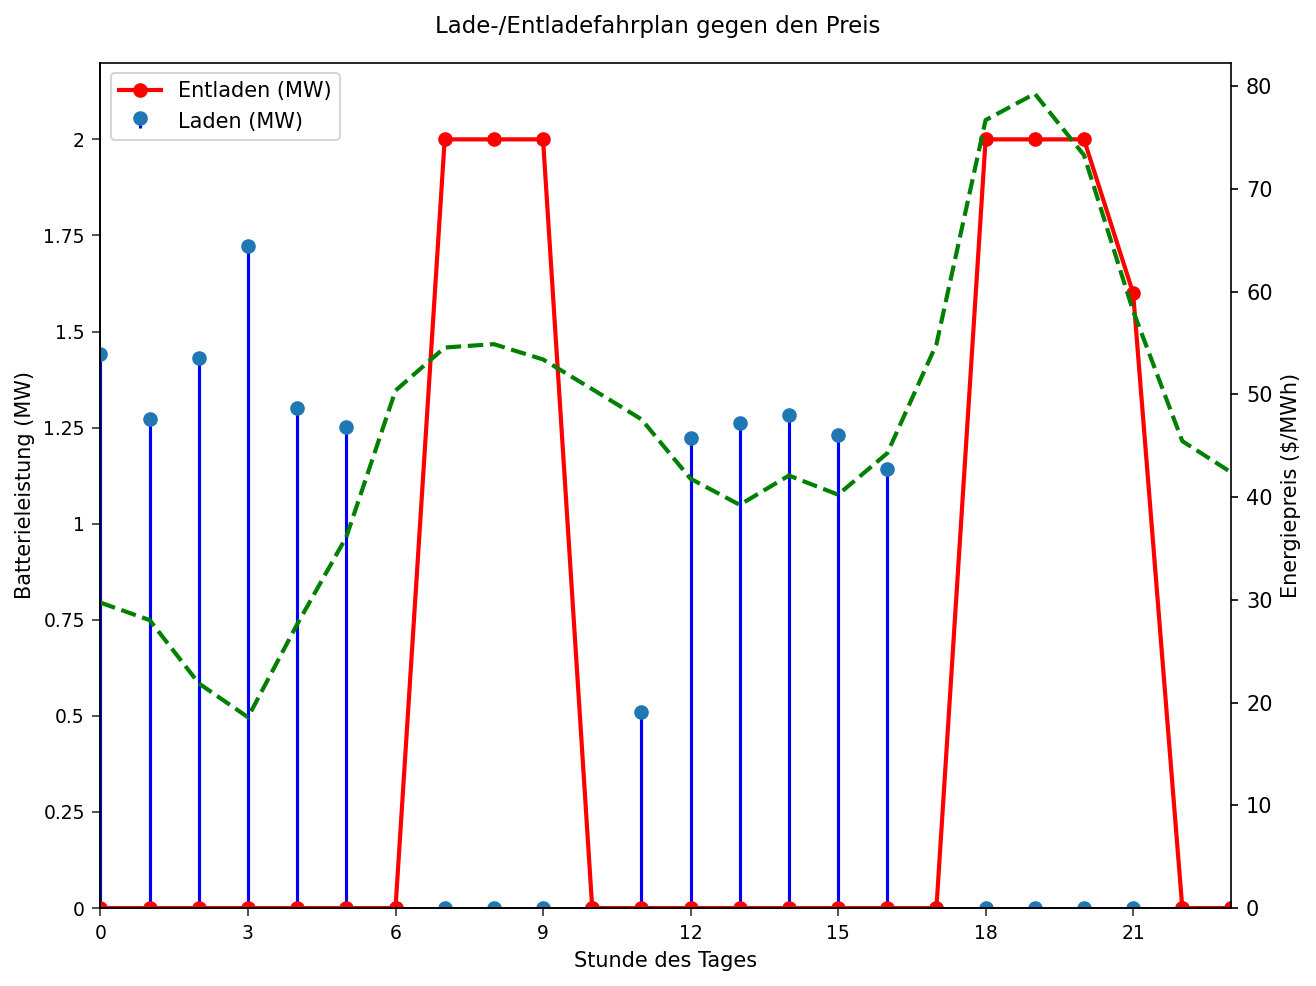

In [8]:
TITEL "Lade-/Entladefahrplan gegen den Preis";
PROZEDUR SGPLOT DATEN=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Laden (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Entladen (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Preis ($/MWh)";
    XAXIS BEZEICHNUNG="Stunde des Tages" VALUES=(0 BIS 23 NACH 3);
    YAXIS BEZEICHNUNG="Batterieleistung (MW)" MIN=0 MAX=2.2;
    y2axis BEZEICHNUNG="Energiepreis ($/MWh)" MIN=0;
AUSFÜHREN;
TITEL;

## 9. Verlauf des Ladezustands

Die gespeicherte Energie steigt, während sich die Batterie über Nacht füllt, sinkt durch jedes Entladefenster ab und überschreitet nie die Obergrenze der nutzbaren Kapazität von 8 MWh (gepunktete Referenz).

                                                Verlauf des Ladezustands                                                




NOTE: Option TITLE changed to Verlauf des Ladezustands.
NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


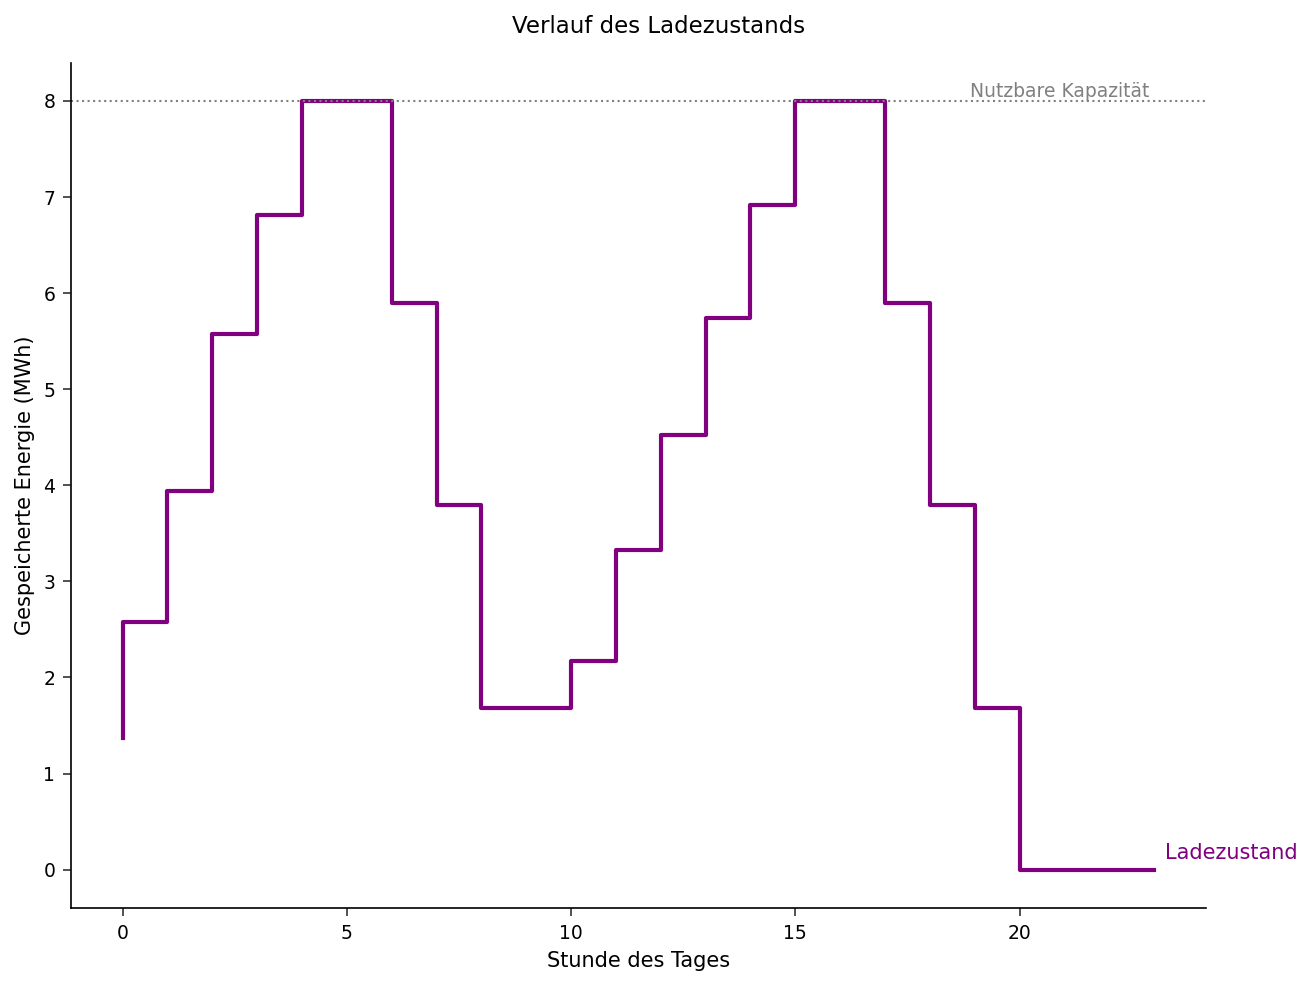

In [9]:
TITEL "Verlauf des Ladezustands";
PROZEDUR SGPLOT DATEN=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="Ladezustand";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        BEZEICHNUNG="Nutzbare Kapazität";
    XAXIS BEZEICHNUNG="Stunde des Tages";
    YAXIS BEZEICHNUNG="Gespeicherte Energie (MWh)";
AUSFÜHREN;
TITEL;

## 10. Netzbezug: vor vs. nach dem Dispatch

Die orangefarbene Linie (Netzbezug mit Batterie) fällt durch die Abendrampe (Stunden 18–21) deutlich unter die gestrichelte Basislast — der Spitzenlastkappungseffekt, der die Leistungsgebühr senkt. Während der nächtlichen und mittäglichen Ladefenster steigt sie, doch der Optimierer deckelt sie auf eine flache Obergrenze von ~3,43 MW, die *unter* der ursprünglichen Lastspitze von 3,59 MW bleibt, sodass das Laden günstige Energie kauft, ohne ein neues abgerechnetes Maximum zu setzen.

                                          Netzbezug: vor vs. nach dem Dispatch                                          




NOTE: Option TITLE changed to Netzbezug: vor vs. nach dem Dispatch.
NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


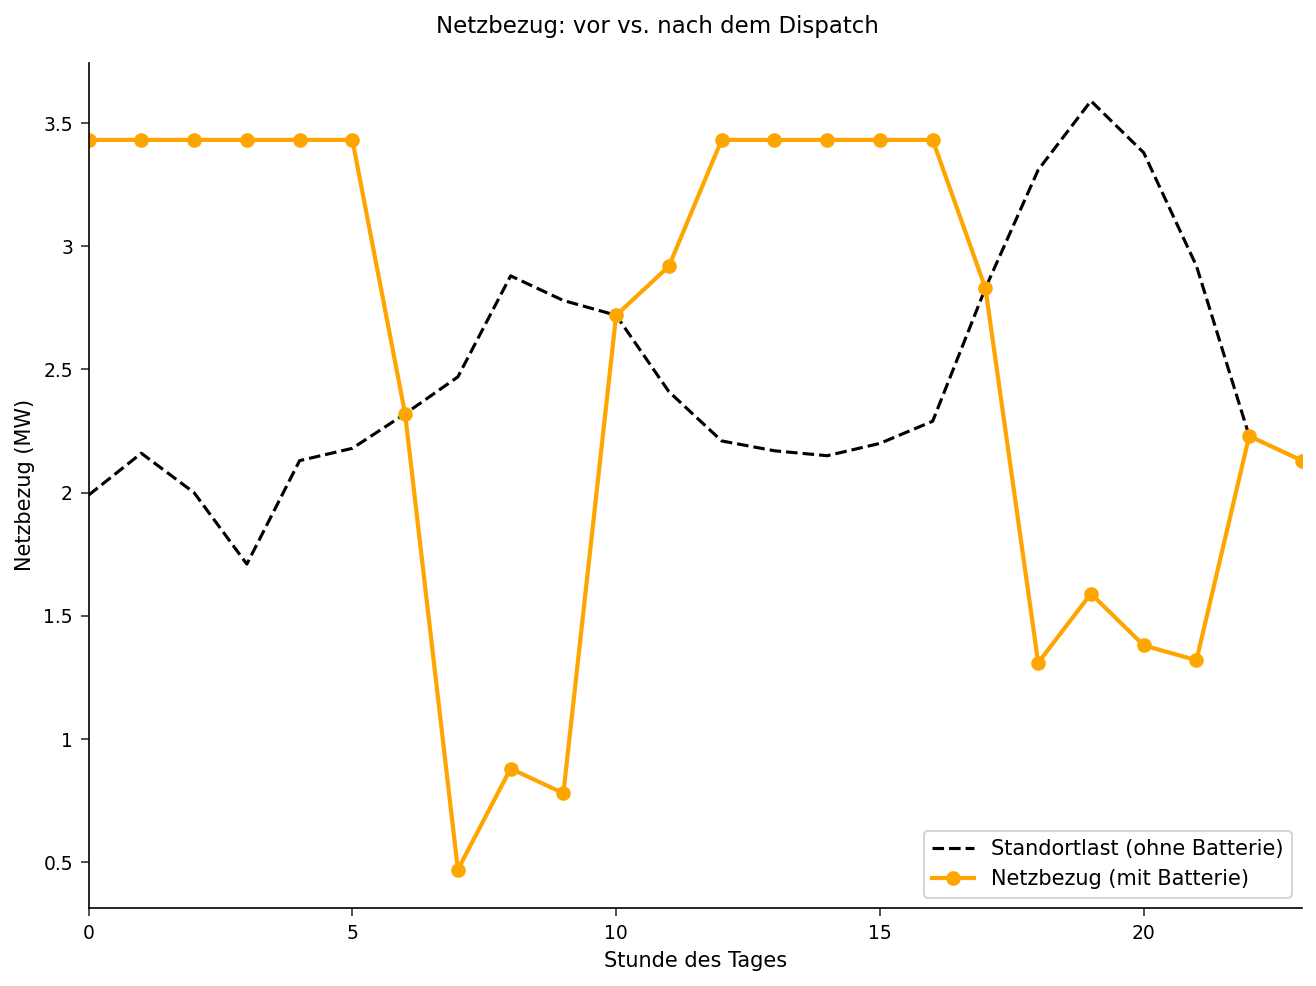

In [10]:
TITEL "Netzbezug: vor vs. nach dem Dispatch";
PROZEDUR SGPLOT DATEN=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Standortlast (ohne Batterie)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Netzbezug (mit Batterie)";
    XAXIS BEZEICHNUNG="Stunde des Tages";
    YAXIS BEZEICHNUNG="Netzbezug (MW)";
AUSFÜHREN;
TITEL;

## Interpretation und nächste Schritte

**Was das Modell entschieden hat.** Obwohl der Umlaufwirkungsgrad jeden Zyklus belastet, fand der Optimierer dennoch klaren Wert: Er füllte die Batterie in den günstigsten Nachtstunden, entlud in die Morgenpreisspitze (Stunden 7–9), lud durch das preisliche Mittagstal nach (Stunden 11–16) und entlud erneut in die reichste Abendspitze (Stunden 18–21). Bezeichnenderweise lud er während der nächtlichen Füllung nur mit 1,0–1,7 MW statt mit der vollen 2-MW-Auslegung — er hielt Leistung zurück, sodass der zusätzliche Netzbezug den Bezug nie über die Lastspitze des Tages drückte. Der Ladezustand respektierte jederzeit sowohl die Kapazität von 8 MWh als auch die Leistungsgrenze von 2 MW.

**Der Geschäftsfall.** Die täglichen Energiekosten fielen von **\$2.903,78 auf \$2.528,43** — **\$375,34 (12,9 %)** Arbitrageersparnis — und das abgerechnete Netzmaximum sank von **3,59 MW auf 3,43 MW** (um etwa **0,16 MW**), was weitere **\$18,98** von der Leistungsgebührenposition abzog. Über die Betriebstage annualisiert plus die wiederkehrende Reduktion der Leistungsgebühr, ist dies die Art von Marge, die eine Speicherinvestition trägt.

**Warum ein LP das richtige Werkzeug ist.** Heuristiken ("unter dem Medianpreis laden, darüber entladen") ignorieren Wirkungsgradverluste, die Kapazitätskopplung über Stunden hinweg und die Tatsache, dass die Leistungsgebühr von einem einzelnen Intervall abhängt — sie würden über Nacht mit voller Leistung laden und die abgerechnete Spitze *erhöhen*, was den Wert der Spitzenlastkappung zerstört. PROC OPTMODEL erfasst all dies in einem deklarativen Modell und liefert den beweisbar optimalen Fahrplan zurück, der hier bewusst die Laderate moderiert, um die Spitze zu schützen.

**Erweiterung des Modells.**

- **Längere Horizonte / mehrtägig** — die Indexmenge `HOURS` verbreitern; tagesübergreifende Zyklusgrenzen hinzufügen.
- **Preisunsicherheit** — das LP über mehrere Preisszenarien lösen und die Erst-Stunden-Entscheidung mitteln (eine rollierende stochastische Politik).
- **Batteriedegradation** — einen Durchsatz-Strafterm oder eine Nebenbedingung auf kumulative Zyklen hinzufügen, um Arbitrage gegen die Lebensdauer des Anlagenguts abzuwägen.
- **Frequenzregelung / Kapazitätsmärkte** — reservierte Headroom-Nebenbedingungen einführen, sodass die Batterie Erlöse aus Systemdienstleistungen auf die Arbitrage aufsatteln kann.

All dies sind inkrementelle Änderungen am selben OPTMODEL-Block — die hier etablierte Struktur trägt unverändert durch.